# Clustering sémantique des titres de thèses

**Objectif :** Regrouper les ~9 200 thèses par proximité sémantique de leur titre, en vue d'une visualisation *bubble graph* dans le dashboard.

**Pipeline :**
1. Chargement et nettoyage des titres (FR + EN)
2. Vectorisation avec `sentence-transformers` (modèle multilingue)
3. Réduction de dimension avec UMAP
4. Clustering avec HDBSCAN
5. Interprétation par TF-IDF par cluster
6. Export `clusters.json` pour le dashboard

## 0. Installation des dépendances

In [ ]:
# À exécuter une seule fois
#! pip install sentence-transformers umap-learn hdbscan langdetect scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 4.1 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 9.9 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 618.0/618.0 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 11.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 8.9 MB/s eta 0:00:00a 0:00:01
  DEPRECATION: Building 'langdetect' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'langdetect'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-non

## 1. Chargement des données

In [6]:
import json
import numpy as np
import pandas as pd

DATA_PATH = '../data/data.json'
OUTPUT_PATH = '../data/clusters.json'
DATA_ENRICHED_PATH = '../data/data_clustered.json'

with open(DATA_PATH, 'r', encoding='utf-8') as f:
    raw = json.load(f)

df = pd.DataFrame(raw)
print(f'Corpus : {len(df)} thèses')
print(f'Colonnes : {list(df.columns)}')
df[['titre', 'cnu_norm', 'annee']].head()

Corpus : 9246 thèses
Colonnes : ['id', 'titre', 'etablissement', 'annee', 'cnu', 'directeurs', 'accessible', 'lat', 'lon', 'cnu_norm', 'etablissement_norm']


,titre,cnu_norm,annee
0,Contributions à la gestion de crise « cyber » ...,Science politique,2022
1,Et pourtant... elles bossent ! : Trajectoires ...,Sociologie,2023
2,Les habitants invisibles des friches de la vil...,Ethnologie,2021
3,Les cercles « halal » : discuter l’islam dans ...,Sociologie,2022
4,Le souci des mères : ethnographie du gouvernem...,Sociologie,2021


In [7]:
# --- Chargement du cache si disponible ---
# Si les embeddings/UMAP/clusters sont déjà calculés, exécutez cette cellule
# et sautez les cellules 3 (vectorisation), 4 (UMAP) et 5 (clustering).
import os
CACHE_DIR = '../data/cache'
_cache_ok = all(os.path.exists(f'{CACHE_DIR}/{f}') for f in
               ['embeddings.npy','umap_2d.npy','umap_10d.npy','cluster_labels.npy'])

if _cache_ok:
    embeddings = np.load(f'{CACHE_DIR}/embeddings.npy')
    emb_2d     = np.load(f'{CACHE_DIR}/umap_2d.npy')
    emb_10d    = np.load(f'{CACHE_DIR}/umap_10d.npy')
    labels     = np.load(f'{CACHE_DIR}/cluster_labels.npy')
    print(f'Cache chargé  — {embeddings.shape[0]} thèses, {len(set(labels))-1} clusters')
else:
    print('Pas de cache — exécutez les cellules vectorisation / UMAP / clustering')

Pas de cache — exécutez les cellules vectorisation / UMAP / clustering


## 2. Prétraitement des titres

In [8]:
import re

# Stopwords FR + EN combinés (pour l'étape TF-IDF uniquement)
STOPWORDS_FR = {
    'le', 'la', 'les', 'de', 'du', 'des', 'un', 'une', 'en', 'et', 'ou',
    'à', 'au', 'aux', 'dans', 'par', 'pour', 'sur', 'sous', 'avec', 'sans',
    'entre', 'vers', 'que', 'qui', 'ce', 'se', 'si', 'ne', 'pas', 'plus',
    'il', 'elle', 'ils', 'elles', 'nous', 'vous', 'je', 'tu', 'on',
    'son', 'sa', 'ses', 'mon', 'ma', 'mes', 'leur', 'leurs',
    'une', 'est', 'sont', 'été', 'être', 'avoir', 'fait', 'faire',
    'cas', 'étude', 'analyse', 'approche', 'recherche', 'contribution',
    'thèse', 'essai', 'travail', 'rapport', 'question', 'perspective','chez'
}

STOPWORDS_EN = {
    'the', 'a', 'an', 'of', 'in', 'on', 'at', 'to', 'for', 'with',
    'and', 'or', 'but', 'is', 'are', 'was', 'were', 'be', 'been',
    'have', 'has', 'had', 'do', 'does', 'did', 'will', 'would',
    'this', 'that', 'these', 'those', 'from', 'by', 'as', 'into',
    'study', 'analysis', 'approach', 'case', 'towards', 'toward',
    'essay', 'contribution', 'evidence', 'perspective', 'thesis',
}

STOPWORDS = STOPWORDS_FR | STOPWORDS_EN

def clean_for_tfidf(text):
    """Nettoyage léger pour TF-IDF (interprétation des clusters)"""
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'[^\w\s\-]', ' ', text)   # retire ponctuation sauf tiret
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = [t for t in text.split() if t not in STOPWORDS and len(t) > 2]
    return ' '.join(tokens)

# Les titres bruts vont au modèle (il gère FR+EN nativement)
df['titre_clean'] = df['titre'].fillna('').astype(str)

# Les titres nettoyés sont réservés au TF-IDF
df['titre_tfidf'] = df['titre_clean'].apply(clean_for_tfidf)

# Retirer les thèses sans titre
mask_valide = df['titre_clean'].str.len() > 5
df_valid = df[mask_valide].copy().reset_index(drop=True)
print(f'Thèses avec titre valide : {len(df_valid)} / {len(df)}')

# Aperçu
df_valid[['titre_clean', 'titre_tfidf']].head(5)

Thèses avec titre valide : 9245 / 9246


,titre_clean,titre_tfidf
0,Contributions à la gestion de crise « cyber » ...,contributions gestion crise cyber juridique ma...
1,Et pourtant... elles bossent ! : Trajectoires ...,pourtant bossent trajectoires migratoires prof...
2,Les habitants invisibles des friches de la vil...,habitants invisibles friches ville abris discr...
3,Les cercles « halal » : discuter l’islam dans ...,cercles halal discuter islam contexte européen...
4,Le souci des mères : ethnographie du gouvernem...,souci mères ethnographie gouvernement maternit...


## 3. Vectorisation — sentence-transformers

Modèle : `paraphrase-multilingual-MiniLM-L12-v2`  
- Multilingue (50+ langues dont FR et EN)  
- Léger (~120 MB), rapide sur CPU  
- Sortie : vecteurs de dimension 384

In [9]:
# Sauvegarde du cache (évite de relancer les étapes longues)
import os
CACHE_DIR = '../data/cache'
os.makedirs(CACHE_DIR, exist_ok=True)
np.save(f'{CACHE_DIR}/embeddings.npy', embeddings)
print(f'Embeddings sauvegardés : {embeddings.shape}')

NameError: name 'embeddings' is not defined

In [10]:
from sentence_transformers import SentenceTransformer

MODEL_NAME = 'paraphrase-multilingual-MiniLM-L12-v2'

print(f'Chargement du modèle {MODEL_NAME}...')
model = SentenceTransformer(MODEL_NAME)

titres = df_valid['titre_clean'].tolist()

print(f'Encodage de {len(titres)} titres...')
embeddings = model.encode(
    titres,
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True,  # cosine similarity friendly
)

print(f'Shape embeddings : {embeddings.shape}')  # (n_theses, 384)

Chargement du modèle paraphrase-multilingual-MiniLM-L12-v2...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encodage de 9245 titres...


Batches:   0%|          | 0/145 [00:00<?, ?it/s]

Shape embeddings : (9245, 384)


## 4. Réduction de dimension — UMAP

Deux réductions :
- **2D** → visualisation scatter
- **10D** → clustering (HDBSCAN fonctionne mieux en dimension intermédiaire)

In [11]:
import umap

print('UMAP 10D pour clustering...')
reducer_10d = umap.UMAP(
    n_components=10,
    n_neighbors=15,
    min_dist=0.0,       # clusters plus compacts
    metric='cosine',
    random_state=42,
)
embeddings_10d = reducer_10d.fit_transform(embeddings)

print('UMAP 2D pour visualisation...')
reducer_2d = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric='cosine',
    random_state=42,
)
embeddings_2d = reducer_2d.fit_transform(embeddings)

df_valid['x'] = embeddings_2d[:, 0].round(4)
df_valid['y'] = embeddings_2d[:, 1].round(4)

print('Done.')

UMAP 10D pour clustering...


/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP 2D pour visualisation...


/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Done.


## 5. Clustering — HDBSCAN

In [12]:
# Sauvegarde UMAP + labels cluster
np.save(f'{CACHE_DIR}/umap_2d.npy', emb_2d)
np.save(f'{CACHE_DIR}/umap_10d.npy', emb_10d)
np.save(f'{CACHE_DIR}/cluster_labels.npy', labels)
print('UMAP 2D, 10D et labels cluster sauvegardés.')

NameError: name 'emb_2d' is not defined

In [17]:
import hdbscan

# min_cluster_size : taille minimale d'un cluster
# Avec ~9 000 thèses, 40–80 est un bon point de départ
MIN_CLUSTER_SIZE = 50

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=MIN_CLUSTER_SIZE,
    min_samples=5,
    metric='euclidean',
    cluster_selection_method='eom',  # excess of mass — clusters bien définis
    prediction_data=True,
)

labels = clusterer.fit_predict(embeddings_10d)

df_valid['cluster_id'] = labels

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = (labels == -1).sum()

print(f'Clusters trouvés  : {n_clusters}')
print(f'Thèses non classées (bruit) : {n_noise} ({n_noise/len(labels)*100:.1f}%)')
print()
print('Distribution des clusters (top 15) :')
print(pd.Series(labels).value_counts().head(15).to_string())

Clusters trouvés  : 42
Thèses non classées (bruit) : 2871 (31.1%)

Distribution des clusters (top 15) :
-1     2871
 37     415
 28     371
 1      334
 17     305
 40     291
 5      267
 35     256
 24     248
 18     230
 19     221
 3      191
 21     187
 15     185
 9      178


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


### Ajuster si besoin

- Trop de clusters (>30) → augmenter `min_cluster_size`  
- Trop peu (<8) → diminuer `min_cluster_size`  
- Trop de bruit (>30%) → diminuer `min_samples`

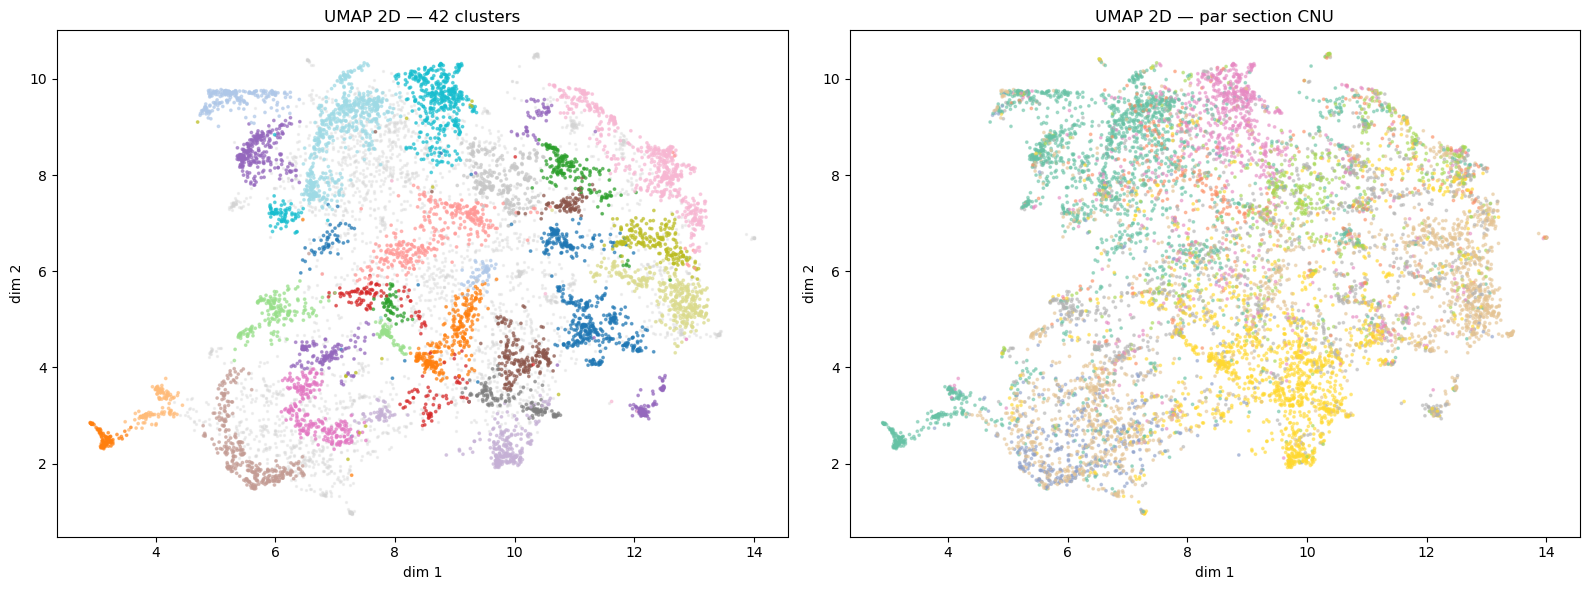

In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter coloré par cluster
scatter_data = df_valid[df_valid['cluster_id'] != -1]
noise_data   = df_valid[df_valid['cluster_id'] == -1]

axes[0].scatter(noise_data['x'], noise_data['y'], c='lightgray', s=2, alpha=0.3, label='bruit')
scatter = axes[0].scatter(
    scatter_data['x'], scatter_data['y'],
    c=scatter_data['cluster_id'], cmap='tab20', s=3, alpha=0.6
)
axes[0].set_title(f'UMAP 2D — {n_clusters} clusters')
axes[0].set_xlabel('dim 1'); axes[0].set_ylabel('dim 2')

# Scatter coloré par section CNU
cnu_codes = df_valid['cnu_norm'].fillna('?').astype('category')
axes[1].scatter(df_valid['x'], df_valid['y'], c=cnu_codes.cat.codes, cmap='Set2', s=3, alpha=0.5)
axes[1].set_title('UMAP 2D — par section CNU')
axes[1].set_xlabel('dim 1'); axes[1].set_ylabel('dim 2')

plt.tight_layout()
plt.savefig('../data/umap_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Interprétation — TF-IDF par cluster

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer

TOP_WORDS = 10  # mots-clés par cluster

# Construire un "document" par cluster (concat des titres nettoyés)
cluster_ids = sorted([c for c in df_valid['cluster_id'].unique() if c != -1])

cluster_docs = {}
for cid in cluster_ids:
    mask = df_valid['cluster_id'] == cid
    cluster_docs[cid] = ' '.join(df_valid.loc[mask, 'titre_tfidf'].tolist())

# TF-IDF sur les documents-clusters
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),   # unigrams + bigrams pour mieux interpréter
    min_df=2,
)
tfidf_matrix = vectorizer.fit_transform(list(cluster_docs.values()))
feature_names = vectorizer.get_feature_names_out()

# Extraire top mots par cluster
cluster_keywords = {}
for i, cid in enumerate(cluster_docs.keys()):
    row = tfidf_matrix[i].toarray().flatten()
    top_idx = row.argsort()[::-1][:TOP_WORDS]
    cluster_keywords[cid] = [feature_names[j] for j in top_idx if row[j] > 0]

# Affichage
print(f'Mots-clés par cluster (top {TOP_WORDS}) :\n')
for cid in cluster_ids:
    n = (df_valid['cluster_id'] == cid).sum()
    kw = ', '.join(cluster_keywords.get(cid, [])[:5])
    print(f'  Cluster {cid:3d} ({n:4d} thèses) → {kw}')

Mots-clés par cluster (top 10) :

  Cluster   0 ( 134 thèses) → chine, chinois, chinoise, china, taïwan
  Cluster   1 ( 334 thèses) → santé, soins, handicap, hôpital, infirmiers
  Cluster   2 (  52 thèses) → architecture, architectural, architecturale, architectes, design
  Cluster   3 ( 191 thèses) → musique, musicale, sonores, musicales, musiques
  Cluster   4 (  50 thèses) → médias, journalisme, news, fake news, fake
  Cluster   5 ( 267 thèses) → numérique, marque, ligne, numériques, consommateurs
  Cluster   6 ( 110 thèses) → atlas, detector, experiment, cms, search
  Cluster   7 (  64 thèses) → ray, cosmologie, gamma ray, gamma, amas
  Cluster   8 (  65 thèses) → experiment, detector, search, dune, decay
  Cluster   9 ( 178 thèses) → femmes, genre, violence, violences, hommes
  Cluster  10 (  53 thèses) → agricole, agriculture, agricoles, durabilité, circuits
  Cluster  11 (  63 thèses) → alimentaire, alimentaires, alimentation, produits, perçue
  Cluster  12 ( 166 thèses) → eaux,

## 7. Label automatique des clusters

Le label est généré à partir des 3 premiers mots TF-IDF du cluster.

In [20]:
def make_label(keywords, n=3):
    """Génère un label lisible depuis les mots-clés TF-IDF."""
    return ' / '.join(keywords[:n]) if keywords else 'non classé'

cluster_labels = {
    cid: make_label(cluster_keywords.get(cid, []))
    for cid in cluster_ids
}
cluster_labels[-1] = 'non classé'

df_valid['cluster_label'] = df_valid['cluster_id'].map(cluster_labels)

# Section CNU majoritaire par cluster
cluster_cnu = (
    df_valid[df_valid['cluster_id'] != -1]
    .groupby('cluster_id')['cnu_norm']
    .agg(lambda x: x.value_counts().index[0] if len(x) > 0 else None)
    .to_dict()
)

print('Labels générés :')
for cid, label in list(cluster_labels.items())[:15]:
    print(f'  {cid:3d} → {label}')

Labels générés :
    0 → chine / chinois / chinoise
    1 → santé / soins / handicap
    2 → architecture / architectural / architecturale
    3 → musique / musicale / sonores
    4 → médias / journalisme / news
    5 → numérique / marque / ligne
    6 → atlas / detector / experiment
    7 → ray / cosmologie / gamma ray
    8 → experiment / detector / search
    9 → femmes / genre / violence
   10 → agricole / agriculture / agricoles
   11 → alimentaire / alimentaires / alimentation
   12 → eaux / océan / pollution
   13 → supply / supply chain / chain
   14 → climatique / changement climatique / changement


## 8. Export pour le dashboard

In [21]:
# --- clusters.json : un objet par cluster pour le bubble graph ---

clusters_export = []
for cid in cluster_ids:
    mask = df_valid['cluster_id'] == cid
    subset = df_valid[mask]
    
    # Centroïde 2D
    cx = float(subset['x'].mean().round(4))
    cy = float(subset['y'].mean().round(4))
    
    clusters_export.append({
        'id': int(cid),
        'label': cluster_labels[cid],
        'keywords': cluster_keywords.get(cid, []),
        'nb': int(mask.sum()),
        'cx': cx,
        'cy': cy,
        'cnu_dominant': cluster_cnu.get(cid),
        # Répartition CNU interne
        'cnu_dist': subset['cnu_norm'].value_counts().to_dict(),
    })

# Trier par taille décroissante
clusters_export.sort(key=lambda c: c['nb'], reverse=True)

with open(OUTPUT_PATH, 'w', encoding='utf-8') as f:
    json.dump(clusters_export, f, ensure_ascii=False, indent=2)

print(f'clusters.json écrit → {len(clusters_export)} clusters')
print(f'Exemple : {clusters_export[0]}')

clusters.json écrit → 42 clusters
Exemple : {'id': 37, 'label': 'philosophie / pensée / foucault', 'keywords': ['philosophie', 'pensée', 'foucault', 'spinoza', 'deleuze', 'hegel', 'critique', 'michel', 'philosophique', 'descartes'], 'nb': 415, 'cx': 8.726300239562988, 'cy': 9.51360034942627, 'cnu_dominant': 'Philosophie', 'cnu_dist': {'Philosophie': 337, 'Arts': 25, 'Sociologie': 17, "Sciences de l'éducation": 9, 'Science politique': 8, 'Ethnologie': 8, 'Info-com': 5, 'Sciences de gestion': 4, 'Épistémologie': 2}}


In [22]:
# --- data_clustered.json : data.json enrichi avec cluster_id + cluster_label + x + y ---

# Remettre cluster_id / label / coords sur les données d'origine
cluster_map = df_valid.set_index('id')[['cluster_id', 'cluster_label', 'x', 'y']].to_dict('index')

enriched = []
for item in raw:
    row = dict(item)
    info = cluster_map.get(row.get('id'))
    if info:
        row['cluster_id']    = int(info['cluster_id'])
        row['cluster_label'] = info['cluster_label']
        row['x']             = info['x']
        row['y']             = info['y']
    else:
        row['cluster_id']    = -1
        row['cluster_label'] = 'non classé'
        row['x']             = None
        row['y']             = None
    enriched.append(row)

with open(DATA_ENRICHED_PATH, 'w', encoding='utf-8') as f:
    json.dump(enriched, f, ensure_ascii=False, indent=2)

print(f'data_clustered.json écrit → {len(enriched)} entrées')

data_clustered.json écrit → 9246 entrées


## 9. Vérification qualitative

Examiner quelques thèses par cluster pour valider la cohérence sémantique.

In [23]:
def inspect_cluster(cid, n=8):
    mask = df_valid['cluster_id'] == cid
    subset = df_valid[mask]
    kw = ', '.join(cluster_keywords.get(cid, [])[:6])
    print(f'=== Cluster {cid} — "{cluster_labels[cid]}" ({mask.sum()} thèses) ===')
    print(f'Mots-clés TF-IDF : {kw}\n')
    for _, row in subset.sample(min(n, len(subset)), random_state=1).iterrows():
        print(f'  [{row["cnu_norm"]}] {row["titre_clean"]}')
    print()

# Inspecter les 5 plus grands clusters
for cid in [c['id'] for c in clusters_export[:5]]:
    inspect_cluster(cid)

=== Cluster 37 — "philosophie / pensée / foucault" (415 thèses) ===
Mots-clés TF-IDF : philosophie, pensée, foucault, spinoza, deleuze, hegel

  [Philosophie] Le concept de pouvoir. Histoire et sens de la controverse entre Michel Foucault et Jean Baudrillard
  [Philosophie] ''R. Ovadiah Sforno, his school in Bologna, his disciple R. Elia di Nola, and a study of their relationship through Nola's commentary on the Psalms''
  [Philosophie] Opérationnaliser l'incertitude morale : définir un cadre d'analyse pour l'esprit critique dans un monde incertain
  [Philosophie] Principium individuationis : C.G. Jung et la philosophie allemande : élaboration de l’oeuvre de Carl Gustav Jung (1875-1961) et étude de ses sources philosophiques
  [Philosophie] Happiness : la genèse d’une confusion : histoire et termes d’un débat entre utilitarisme et idéalisme
  [Philosophie] Média et systèmes d'inscription dans la pensée de Friedrich Kittler : une lecture allemande de Jacques Lacan, Michel Foucault et Ja

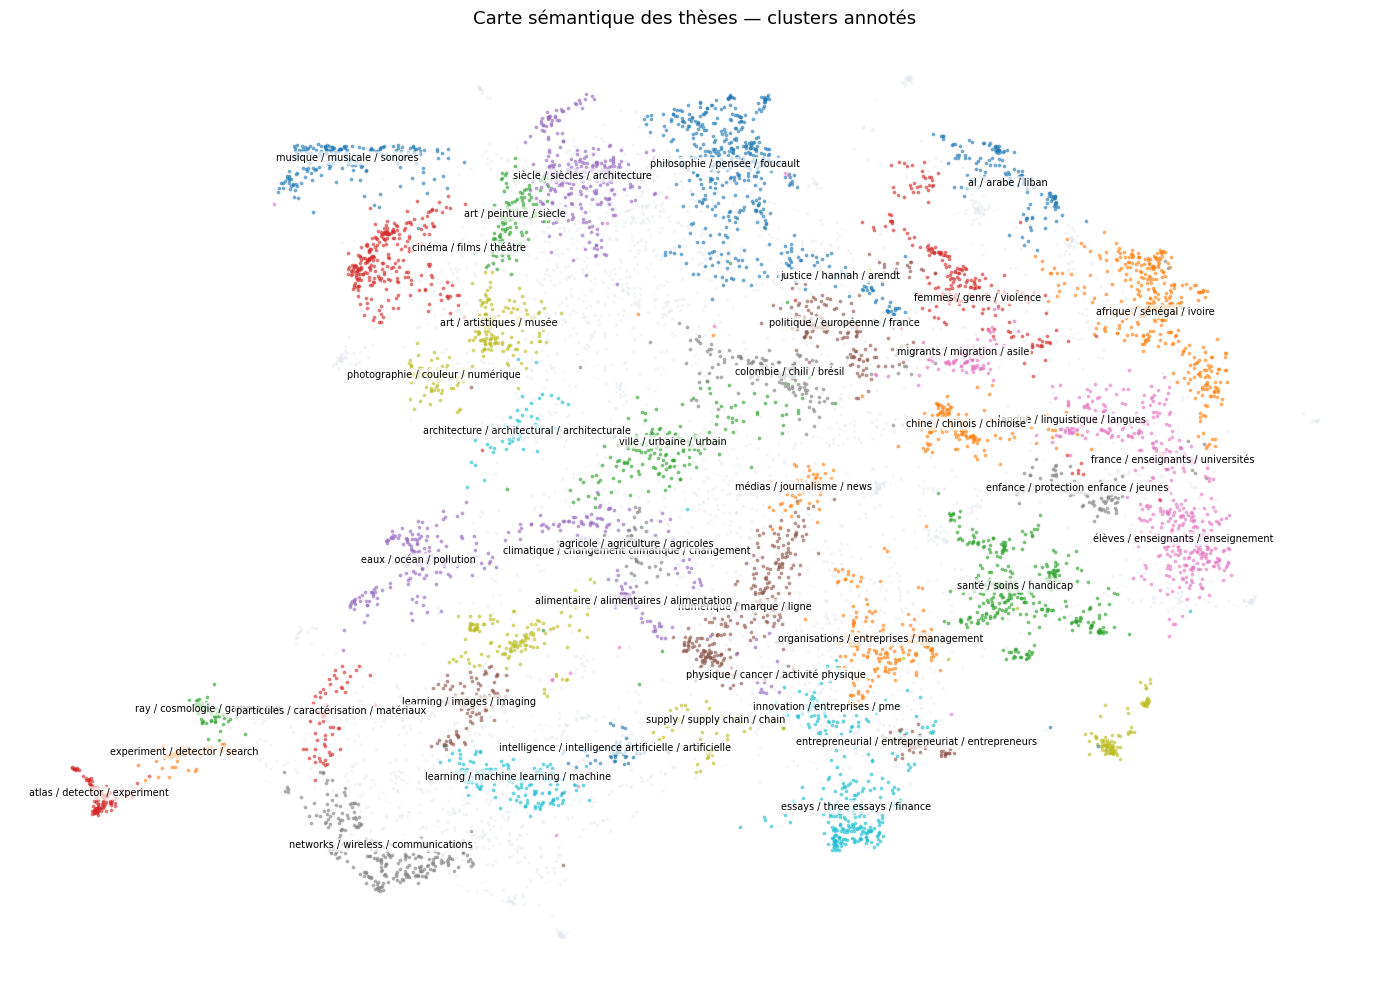

In [24]:
# Scatter final annoté avec les labels
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 10))

noise = df_valid[df_valid['cluster_id'] == -1]
ax.scatter(noise['x'], noise['y'], c='#e2e8f0', s=2, alpha=0.3)

for c in clusters_export:
    mask = df_valid['cluster_id'] == c['id']
    subset = df_valid[mask]
    ax.scatter(subset['x'], subset['y'], s=3, alpha=0.5, label=c['label'])
    ax.annotate(
        c['label'],
        xy=(c['cx'], c['cy']),
        fontsize=7,
        ha='center',
        bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7, ec='none')
    )

ax.set_title('Carte sémantique des thèses — clusters annotés', fontsize=13)
ax.axis('off')
plt.tight_layout()
plt.savefig('../data/umap_annotated.png', dpi=150, bbox_inches='tight')
plt.show()

## Récapitulatif des sorties

| Fichier | Contenu |
|---|---|
| `data/clusters.json` | Un objet par cluster : label, keywords, nb, centroïde 2D, CNU dominant |
| `data/data_clustered.json` | `data.json` enrichi avec `cluster_id`, `cluster_label`, `x`, `y` |
| `data/umap_clusters.png` | Scatter UMAP coloré par cluster et par CNU |
| `data/umap_annotated.png` | Scatter annoté avec les labels des clusters |

Ces fichiers alimentent l'onglet **Disciplines** du dashboard React.